In [1]:
from rabtracks import * 
sns.set_context("paper")

In [2]:
def plot_boolean(ax, time, values, color="C0", hatch = '.', alpha=0.5, label=None):
    time = time - np.timedelta64(3, 'h')
    diff = np.diff(values.astype(int), prepend=0, append=0)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    
    for i, (s, e) in enumerate(zip(starts, ends)):
        ax.axvspan(time[s], time[min(e, len(time)-1)], 
                   facecolor=color, alpha=alpha,
                   label=label if i == 0 else None,
                  hatch = hatch, edgecolor='black',)
    ax.set_yticks([])

In [3]:
def plot_categorical(ax, time, values, color_map=labels_colors, hatch_map=labels_hatches, alpha=0.5):
    """
    Parameters
    ----------
    ax : matplotlib axes
    time : array of datetime values
    values : array of categorical labels (e.g., ["TC", "ETC", "TC", ...])
    color_map : dict mapping each label to a color, e.g. {"TC": "red", "ETC": "dodgerblue"}
    hatch_map : dict mapping each label to a hatch pattern (optional), e.g. {"TC": "//", "ETC": ".."}
    alpha : float
    """
    time = time - np.timedelta64(3, 'h')
    if hatch_map is None:
        hatch_map = {}

    seen_labels = set()

    for label, color in color_map.items():
        mask = (values == label).astype(int)
        diff = np.diff(mask, prepend=0, append=0)
        starts = np.where(diff == 1)[0]
        ends = np.where(diff == -1)[0]

        for i, (s, e) in enumerate(zip(starts, ends)):
            ax.axvspan(time[s], time[min(e, len(time)-1)],
                       facecolor=color, alpha=alpha,
                       hatch=hatch_map.get(label, ''),
                       edgecolor='black',
                       label=label if label not in seen_labels else None)
            seen_labels.add(label)

    ax.set_yticks([])

In [4]:
def plot_ET_lines(T, ax):
    if T.ET.max() == +1:
        ET_onset = T.time.sel(record = T.ET.idxmax())
        ax.axvline(x = ET_onset.values, color = "k", lw=5, label = "ET starts")
    if T.ET.min() == -1:
        ET_offset = T.time.sel(record = T.ET.idxmin())
        ax.axvline(x = ET_offset.values, color = "k", linestyle = ":", lw=5, label = "ET ends")

In [5]:
def plot_flags4TRACK(ax_top, ax_bottom, name, season, eib, s):
    TRACK = eib.where((eib.name == name) & (eib.time.dt.year == season), drop = True)
    T = TRACK.sel(source = s)

    # Plot flags
    plot_boolean(ax_top, T.time.values, T.WCS.values, label="WCS", color = "orange", hatch = '/')
    plot_boolean(ax_top, T.time.values, T.WCSI.values, label="WCSI", color = "red", hatch = '///')
    plot_boolean(ax_top, T.time.values, T.CCA.values, label="CCA", color = "dodgerblue")
    plot_boolean(ax_bottom, T.time.values, T.is_tc.values, label="is_tc", color = "red", hatch = "//")
    plot_boolean(ax_bottom, T.time.values, T.is_etc.values, label="is_etc", color = "dodgerblue", hatch = "..")

    # Plot ET onset/offset
    plot_ET_lines(T, ax_bottom)

    ax_top.set_ylabel("CPS")
    ax_bottom.set_ylabel("flags")

In [6]:
def plot_flags4IBTrACS_or_SyCLoPS(ax_top, ax_bottom, name, season, eib, s, label_var = "nature"):
    TRACK = eib.where((eib.name == name) & (eib.time.dt.year == season), drop = True)
    T = TRACK.sel(source = s)

    # Plot flags
    plot_categorical(ax_top, T.time.values, T[label_var].astype(str).values)
    plot_boolean(ax_bottom, T.time.values, T.is_tc.fillna(0).values, label="is_tc", color = "red", hatch = "//")
    plot_boolean(ax_bottom, T.time.values, T.is_etc.values, label="is_etc", color = "dodgerblue", hatch = "..")

    # Plot ET onset/offset
    plot_ET_lines(T, ax_bottom)

    ax_top.set_ylabel(label_var)
    ax_bottom.set_ylabel("flags")

In [7]:
def plot_flags(eib, name, season, S = ['IBTrACS', 
            'SyCLoPS-ERA5', 'SyCLoPS-JRA3Q', 'SyCLoPS-MERRA2',
            'TRACK-ERA5', 'TRACK-JRA3Q',],):

    eib = eib.sel(source = S)
    TRACK = eib.where((eib.name == name) & (eib.time.dt.year == season), drop = True)

    # Remove TRACK if no CPS params
    S = [s for s in S if (not s.startswith("TRACK-")) | ((~TRACK.sel(source = s).b.isnull()).sum() > 0)] 
    # Remove SyCLoPS if no label
    S = [s for s in S if (not s.startswith("SyCLoPS-")) | ((~(TRACK.sel(source = "SyCLoPS-ERA5").label.astype(str) == '')).sum() > 0)] 
    
    Ns = len(S)
    fig, axs = plt.subplots(2*Ns, figsize=cm2inch([20, 3*Ns]), sharex = True)
    
    fig.suptitle(name+' ('+str(season)+')', fontweight = "bold")
    for i, s in enumerate(S):
        axs[i*2+0].set_title(s, style='italic')
        if s == "IBTrACS":
            plot_flags4IBTrACS_or_SyCLoPS(axs[i*2+0], axs[i*2+1], name, season, eib, s, label_var = "nature")
        if s.startswith("TRACK-"):
            plot_flags4TRACK(axs[i*2+0], axs[i*2+1], name, season, eib, s)
        if s.startswith("SyCLoPS-"):
            plot_flags4IBTrACS_or_SyCLoPS(axs[i*2+0], axs[i*2+1], name, season, eib, s, label_var = "label")
    
    alphabet = "abcdefghijklmn"
    for i, ax in enumerate(axs):
        ax.grid()
        ax.text(-0.05, 0.5, alphabet[i]+')',
                transform=ax.transAxes, #fontweight='bold', fontsize=12,
                va='center', ha='left')
    
    # Legend
    handles = {}
    for ax in axs:
        for h, l in zip(*ax.get_legend_handles_labels()):
            handles[l] = h

    nrows = 3
    Ls = [["is_tc", "is_etc"], ib_natures, ["WCS", "CCA", "WCSI"], SyCLoPS_labels, ["ET starts", "ET ends"]]
    titles = ["flags", "IBTrACS nature", "CPS stage", "SyCLoPS labels", "ET times"]
    
    x = -0.02
    spacing = 0.02
    for i in range(len(Ls)):
        L = list(set(Ls[i]) & set(handles.keys()))
        if len(L) == 0:
            continue
        leg = fig.legend([handles[l] for l in L], L, 
                   title=titles[i], title_fontproperties=dict(weight="bold"),
                   bbox_to_anchor=(x, -0.), loc='upper left',
                   frameon=False, handlelength=3, handleheight=1.5,
                   ncols=int(np.ceil(len(L) / nrows)))
        fig.canvas.draw()
        bb = leg.get_window_extent().transformed(fig.transFigure.inverted())
        x = bb.x1 + spacing  # next legend starts after this one

    # Draw the figure so legend positions are computed
    fig.canvas.draw()
    
    # Gather bounding boxes of all legends in figure coordinates
    bboxes = []
    for legend in fig.legends:
        bb = legend.get_window_extent().transformed(fig.transFigure.inverted())
        bboxes.append(bb)
    
    # Compute the overall bounding box
    x0 = min(bb.x0 for bb in bboxes)
    y0 = min(bb.y0 for bb in bboxes)
    x1 = max(bb.x1 for bb in bboxes)
    y1 = max(bb.y1 for bb in bboxes)
    
    pad = 0.01  # padding around the legends
    frame = FancyBboxPatch((x0 - pad, y0 - pad), 
                            (x1 - x0) + 2 * pad, 
                            (y1 - y0) + 2 * pad,
                            boxstyle="round,pad=0.",
                            transform=fig.transFigure,
                            facecolor="white", edgecolor="grey",
                            linewidth=1, zorder=0)
    fig.patches.append(frame)

    # Internal vertical separators
    for left, right in zip(bboxes[:-1], bboxes[1:]):
        x = (left.x1 + right.x0) / 2
        fig.add_artist(plt.Line2D([x, x], [y0 - pad, y1 + pad], transform=fig.transFigure,
                                  color='grey', linewidth=0.8, clip_on=False))
    
    axs[-1].xaxis.set_minor_locator(HourLocator(byhour=[0, 6, 12, 18]))
    #axs[-1].xaxis.set_major_locator(HourLocator(byhour=0))
    axs[-1].xaxis.set_major_formatter(DateFormatter('%d %b'))
    
    plt.tight_layout(h_pad = 0.2, w_pad = 0.5)

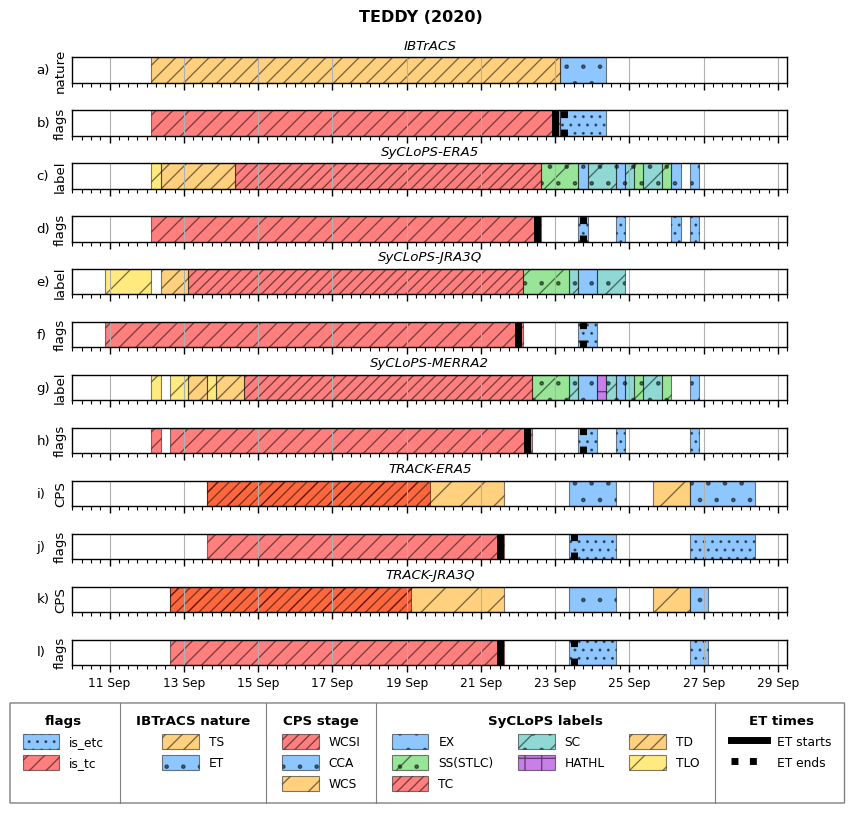

In [25]:
b = "NA"
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
name, season = "TEDDY", 2020

plot_flags(eib, name, season,)

plt.savefig("flags.png", bbox_inches = "tight")
plt.savefig("flags.pdf", bbox_inches = "tight")

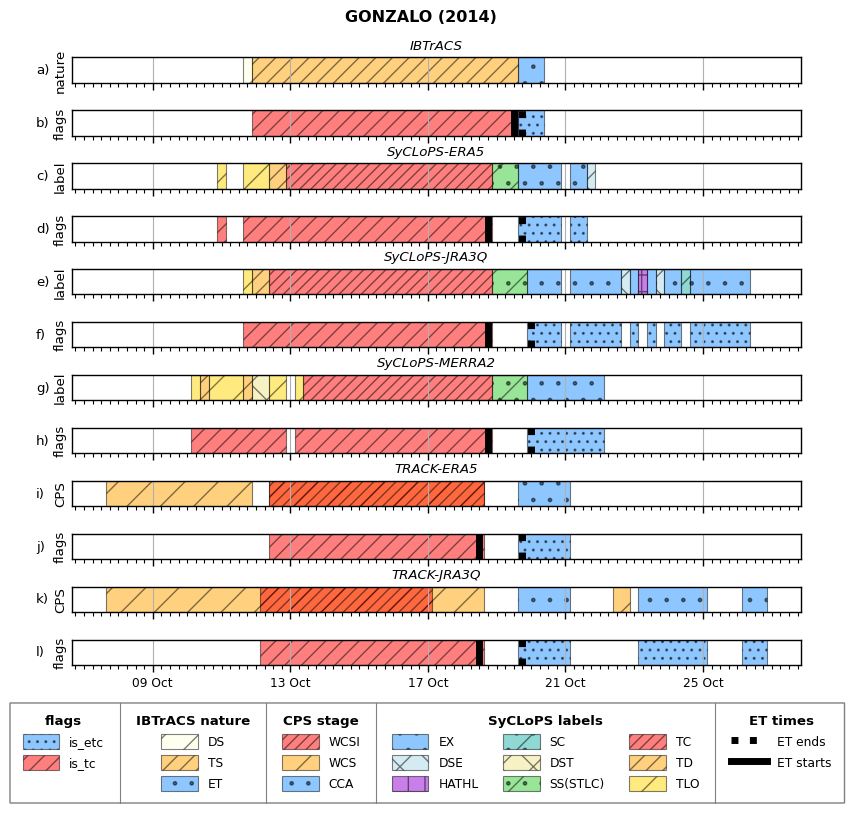

In [8]:
b = "NA"
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
name, season = "GONZALO", 2014

plot_flags(eib, name, season,)

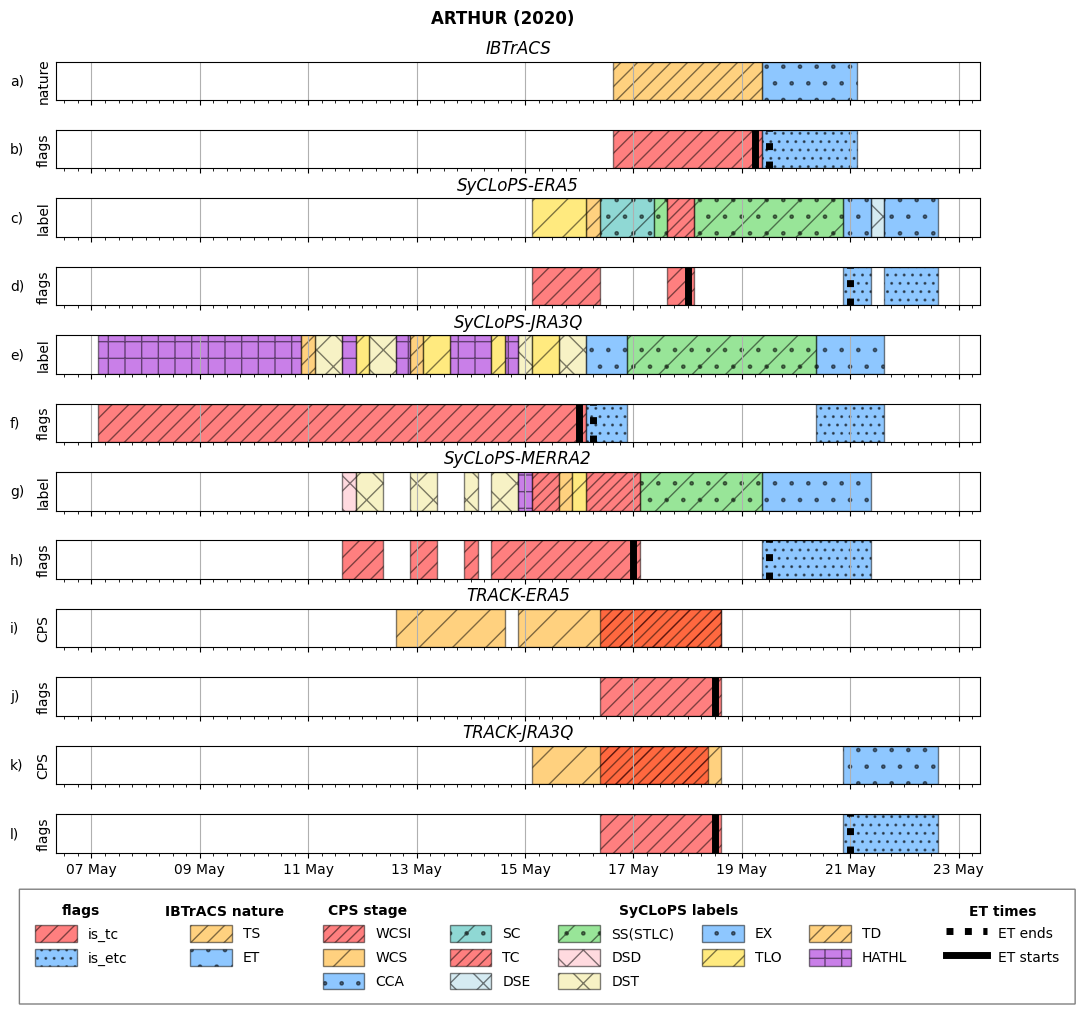

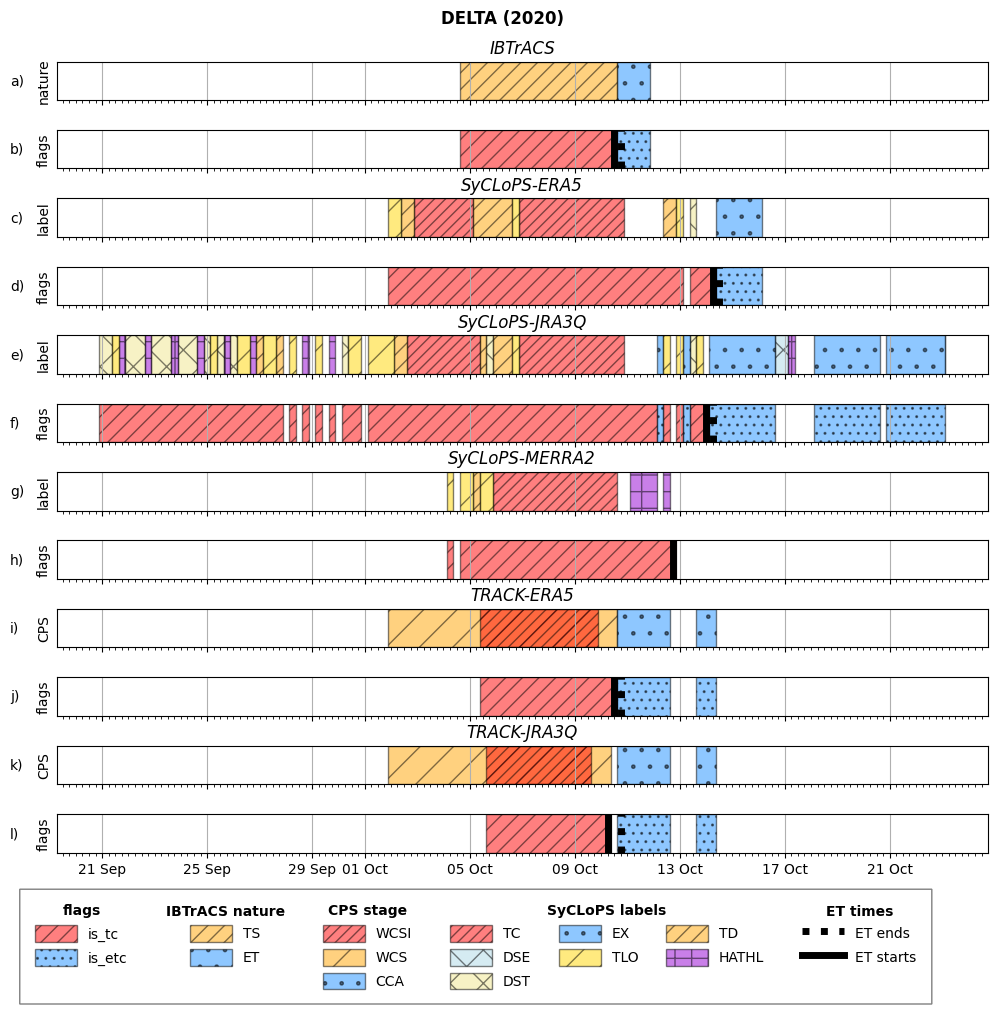

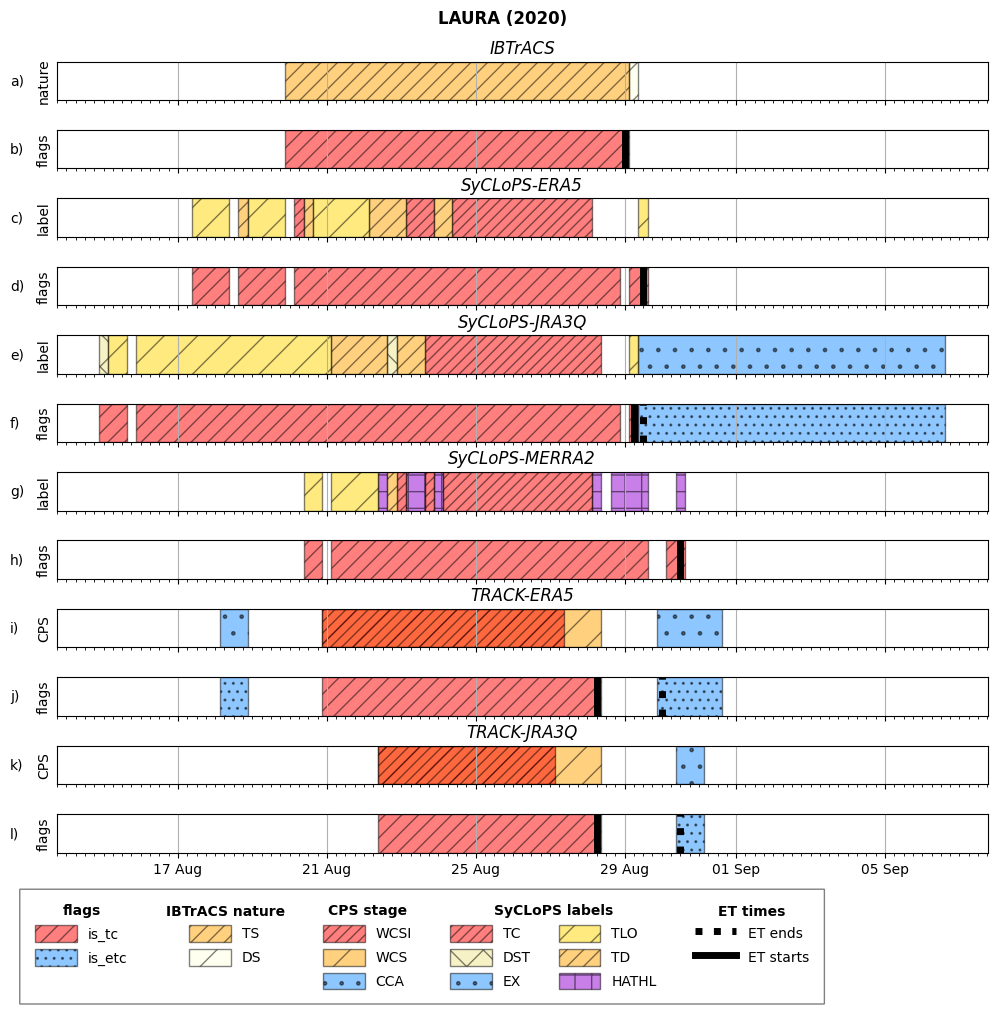

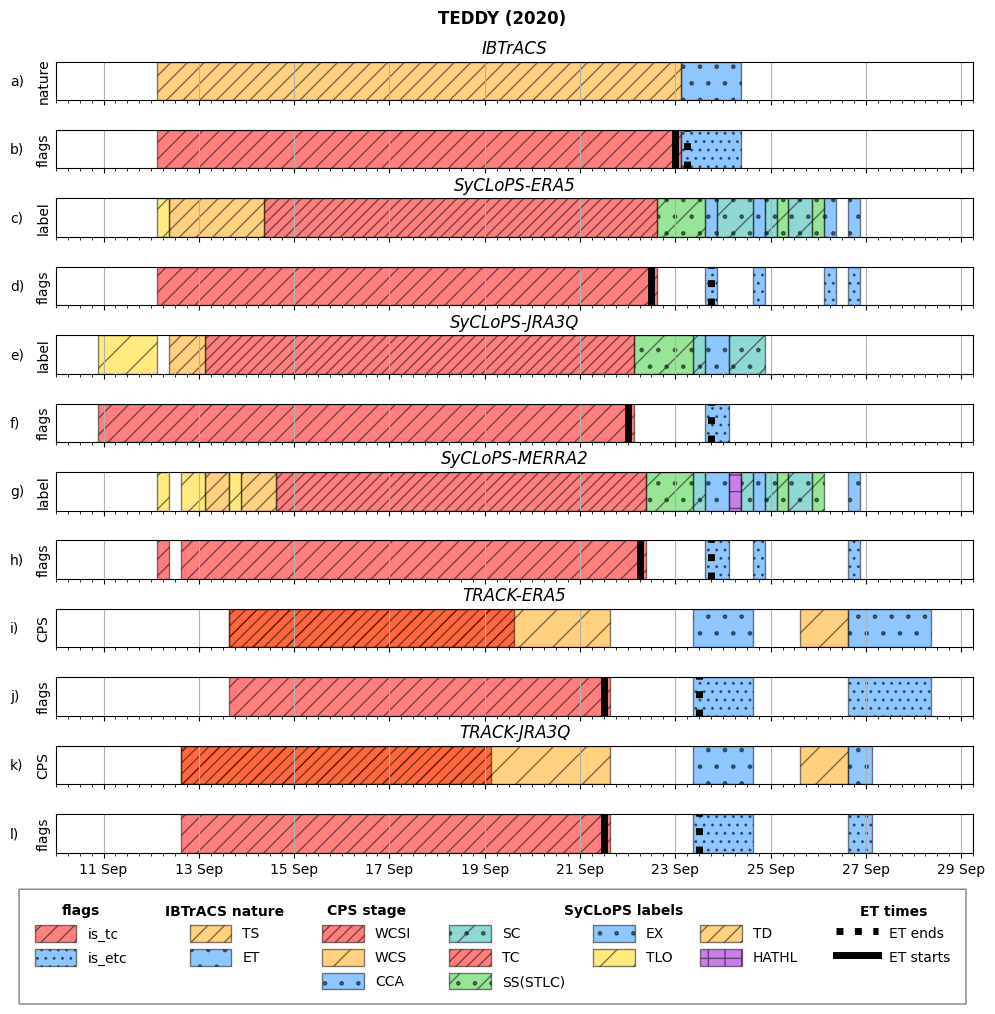

In [11]:
# Plot a few TCs 
names = ["ARTHUR", "DELTA", "LAURA", "TEDDY",]
for name in names:
    plot_flags(eib, name, season,)

In [ ]:
# Plot All 2020 TCs
names = np.unique(eib.where(eib.season == 2020, drop = True).name.values)
for name in names:
    plot_flags(eib, name, season,)

/tmp/ipykernel_6500/3175234145.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(2*Ns, figsize=(10, 1.5*Ns), sharex = True)
